<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/EDA%20%26%20Feature%20Engineering/All_Feat_Excel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import mutual_info_classif

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import MinMaxScaler


In [2]:
# read dataset
excel_df = pd.read_csv('/content/Excel_All_Features.csv')

In [3]:
# define needed functions to test the model and compare evaluation results between each experiment

def get_models():
    """Returns a fresh set of the three classifiers, untrained."""
    return {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy='constant', fill_value=0)),
        ("model", RandomForestClassifier(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        ))
    ]),
        "XGBoost": XGBClassifier(random_state=42)
    }

def evaluate_models(X_train, X_test, y_train, y_test, experiment_name="experiment"):
    """Trains all 3 models and returns a results DataFrame with metrics for each."""
    models = get_models()
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results.append({
            "Experiment": experiment_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='macro'),
            "Recall": recall_score(y_test, y_pred, average='macro'),
            "F1": f1_score(y_test, y_pred, average='macro')
        })
    return pd.DataFrame(results)

def run_experiment(df_input, feature_list, label_col='label', experiment_name="experiment", test_size=0.3):
    """Full pipeline: split data, train, evaluate — given a dataframe and feature list."""
    X = df_input[feature_list]
    y = df_input[label_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    return evaluate_models(X_train, X_test, y_train, y_test, experiment_name)

def compare_experiments(*result_dfs):
    """Stacks multiple experiment result DataFrames into one combined comparison table."""
    combined = pd.concat(result_dfs, ignore_index=True)
    return combined.pivot(index='Model', columns='Experiment')

# Exploratory Data Analysis (EDA)

## Dataset Dimensions, columns and statistics

In [4]:
print("Dataset Dimensions:", excel_df.shape)
print("\nData Columns:")
print(excel_df.info())
print("\nFirst 5 rows:")
excel_df.head()

Dataset Dimensions: (20000, 50)

Data Columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 50 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   file_path                        20000 non-null  object 
 1   file_size                        20000 non-null  int64  
 2   sheet_count                      20000 non-null  int64  
 3   max_rows                         20000 non-null  int64  
 4   max_cols                         20000 non-null  int64  
 5   total_cells                      20000 non-null  int64  
 6   non_empty_cells                  20000 non-null  int64  
 7   numeric_cell_count               20000 non-null  int64  
 8   string_cell_count                20000 non-null  int64  
 9   formula_count                    20000 non-null  int64  
 10  hyperlink_count                  20000 non-null  int64  
 11  avg_cell_length                  

,file_path,file_size,sheet_count,max_rows,max_cols,total_cells,non_empty_cells,numeric_cell_count,string_cell_count,formula_count,...,macro_count_parentheses,macro_count_assignments,macro_max_line_length,macro_max_string_literals,macro_max_arithmetic_ops,macro_max_concat_ops,macro_vocab_size,preview_image_width,preview_image_height,label
0,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,739072,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,/content/drive/MyDrive/UNB/Mastercard project/...,58846,1,450,12,5400,4652,1579,3073,0,...,0,0,35,0,2,0,5211,0,0,0
2,/content/drive/MyDrive/UNB/Mastercard project/...,223714,2,2516,10,25164,19458,6445,13013,1,...,2,1,39,0,2,0,12384,0,0,0
3,/content/drive/MyDrive/UNB/Mastercard project/...,506774,4,2742,18,59955,46267,15349,30918,3,...,6,3,39,0,2,0,17441,0,0,0
4,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,155136,1,117,12,1404,10,1,9,0,...,6,11,3080,14,2,14,78,0,0,1


In [5]:
excel_df.describe().T

,count,mean,std,min,25%,50%,75%,max
file_size,20000.0,308284.113450,377999.468479,4597.0,107127.250000,210285.500000,366514.500000,1.240144e+07
sheet_count,20000.0,3.198750,2.782469,1.0,1.000000,3.000000,4.000000,8.900000e+01
max_rows,20000.0,1100.140400,1358.255603,1.0,52.000000,510.000000,2152.000000,6.552800e+04
max_cols,20000.0,42.523700,436.609094,1.0,12.000000,17.000000,20.000000,1.638400e+04
total_cells,20000.0,41459.543400,255352.418366,1.0,1383.000000,12002.500000,39539.250000,3.074707e+07
non_empty_cells,20000.0,15825.163800,23021.472465,0.0,68.000000,1913.000000,27142.250000,6.858890e+05
numeric_cell_count,20000.0,5290.849100,8168.264148,0.0,3.000000,630.000000,9035.500000,4.471700e+05
string_cell_count,20000.0,10531.863500,15409.635573,0.0,64.000000,1078.000000,18111.250000,4.701820e+05
formula_count,20000.0,38.692850,1634.624229,0.0,0.000000,0.000000,2.000000,1.958510e+05
hyperlink_count,20000.0,0.786300,36.267207,0.0,0.000000,0.000000,0.000000,3.387000e+03


##Check class balance, missing values, and duplicates




In [6]:
# Class balance
print(excel_df['label'].value_counts())
print(excel_df['label'].value_counts(normalize=True))

# Missing values
print("\nMissing values per column:")
print(excel_df.isnull().sum()[excel_df.isnull().sum() > 0])

# Exact duplicate rows (excluding file_path, since paths are always unique)
feature_cols = excel_df.columns.drop(['file_path', 'label'])
dupe_count = excel_df.duplicated(subset=feature_cols).sum()
print(f"\nExact duplicate feature rows: {dupe_count}")

# Quick stats on the feature we noticed with only one value along the column
print("\npreview_image_text_entropy sample values:")
print(excel_df['preview_image_text_entropy'].describe())

print("\nRows with suspiciously tiny total_cells but large file_size:")
print(excel_df[(excel_df['total_cells'] < 5) & (excel_df['file_size'] > 100000)].shape[0], "such rows")

label
1    10000
0    10000
Name: count, dtype: int64
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Missing values per column:
Series([], dtype: int64)

Exact duplicate feature rows: 6028

preview_image_text_entropy sample values:
count    20000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: preview_image_text_entropy, dtype: float64

Rows with suspiciously tiny total_cells but large file_size:
537 such rows


### Summary of Data Analysis
- Data is balanced: 50% malicious & 50% benign
- No missing values exists
- preview_image_text_entropy contains all 0's throughout the entire column and probably other features too in the dataset
- 537 rows has a large file_size with very few # of cells, which might infer that an excel file may appear small or barely empty but contains hidden payload!
- 6028 rows associated with duplications

## Correlation Analysis

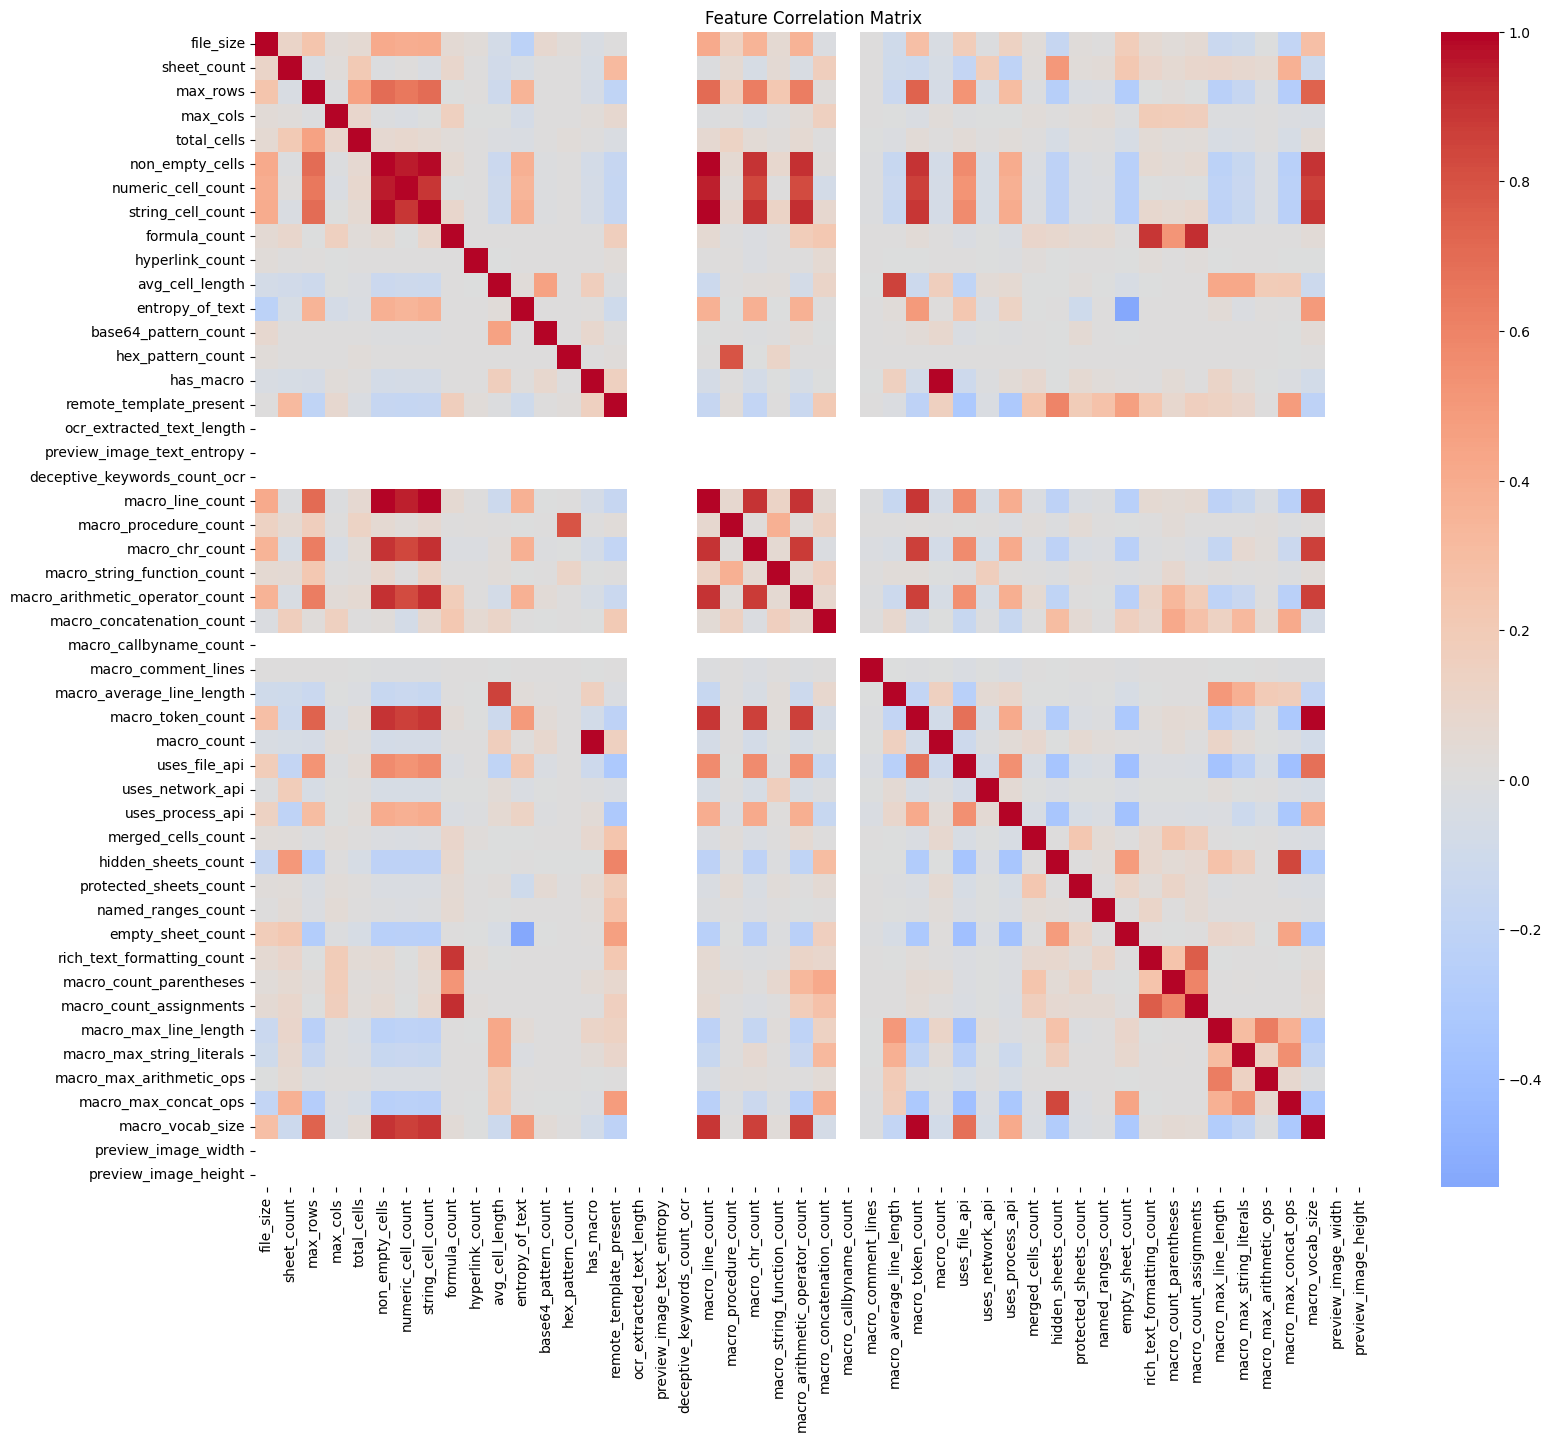

In [7]:
# Compute the correlation matrix
corr = excel_df.drop(columns=["file_path","label"]).corr()

plt.figure(figsize=(18, 15))

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Feature Correlation Matrix")
plt.show()

### Calculate Correlation for all features against the label

In [8]:
# The Correlation of all features with the label
feature_cols = excel_df.columns.drop(['file_path', 'label'])

correlations = excel_df[feature_cols].corrwith(excel_df['label']).sort_values(key=abs, ascending=False)
print(correlations.head(15))
print(correlations.tail(15))

macro_vocab_size                  -0.859118
macro_token_count                 -0.859118
macro_chr_count                   -0.659048
non_empty_cells                   -0.652187
string_cell_count                 -0.651388
macro_line_count                  -0.644766
uses_file_api                     -0.634982
macro_arithmetic_operator_count   -0.634368
max_rows                          -0.624113
numeric_cell_count                -0.609566
entropy_of_text                   -0.570302
empty_sheet_count                  0.361135
macro_max_concat_ops               0.355884
macro_max_line_length              0.336294
hidden_sheets_count                0.323310
dtype: float64
macro_count_assignments         0.025141
macro_comment_lines             0.023164
formula_count                   0.023001
hyperlink_count                 0.021681
macro_count_parentheses         0.020121
base64_pattern_count            0.019865
rich_text_formatting_count      0.018614
total_cells                     0.0150

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Calculate Correlation for all macro features against each other

In [9]:
# The correlation of all macro features (total of 18 feature)
all_macro_features = ['has_macro', 'macro_chr_count',
                          'macro_line_count', 'macro_token_count', 'macro_string_function_count',
                          'macro_arithmetic_operator_count', 'macro_concatenation_count',
                        'macro_procedure_count', 'macro_comment_lines', 'macro_average_line_length', 'macro_max_line_length',
                        'macro_max_string_literals', 'macro_max_concat_ops', 'macro_count_assignments', 'macro_count_parentheses']

print(excel_df[all_macro_features].corr())

                                 has_macro  macro_chr_count  macro_line_count  \
has_macro                         1.000000        -0.070195         -0.066716   
macro_chr_count                  -0.070195         1.000000          0.898317   
macro_line_count                 -0.066716         0.898317          1.000000   
macro_token_count                -0.083099         0.857374          0.893361   
macro_string_function_count      -0.003939         0.053922          0.119625   
macro_arithmetic_operator_count  -0.048445         0.876208          0.900971   
macro_concatenation_count        -0.005135        -0.017676          0.042889   
macro_procedure_count            -0.001365         0.018077          0.071116   
macro_comment_lines              -0.002454        -0.015227         -0.009088   
macro_average_line_length         0.150254        -0.040564         -0.146555   
macro_max_line_length             0.117083        -0.169710         -0.216834   
macro_max_string_literals   

### Calculate The Correlation between suspicted identical features


In [10]:
feature_cols = excel_df.columns.drop(['file_path', 'label'])

macro_presence_corr = excel_df[feature_cols].corrwith(excel_df['macro_count']).sort_values(ascending=False)
print(macro_presence_corr.head())


macro_count                  1.000000
has_macro                    1.000000
avg_cell_length              0.164027
remote_template_present      0.152034
macro_average_line_length    0.150254
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [11]:
feature_cols = excel_df.columns.drop(['file_path', 'label'])

macro_corr = excel_df[feature_cols].corrwith(excel_df['macro_token_count']).sort_values(ascending=False)
print(macro_corr.head())

macro_vocab_size     1.000000
macro_token_count    1.000000
non_empty_cells      0.899972
macro_line_count     0.893361
string_cell_count    0.890531
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]




> macro_count and macro_vocab_size are redundant features, so drop them to avoid noisy data



In [12]:
excel_df = excel_df.drop(columns=['macro_vocab_size', 'macro_count'])

## Check Unique Values

In [13]:
excel_df.nunique()

,0
file_path,20000
file_size,12902
sheet_count,40
max_rows,2856
max_cols,158
total_cells,10195
non_empty_cells,9963
numeric_cell_count,8424
string_cell_count,9524
formula_count,173


In [14]:
# check binary-valued features
print (excel_df['has_macro'].unique())
print (excel_df['hex_pattern_count'].unique())
print (excel_df['uses_file_api'].unique())
print (excel_df['uses_network_api'].unique())
print (excel_df['uses_process_api'].unique())

[0 1]
[ 0 19]
[0 1]
[0 1]
[0 1]


In [15]:
feature_cols = excel_df.columns.drop(['file_path', 'label'])

# 1. Fully dead columns: only ONE unique value across all rows
dead_cols = [col for col in feature_cols if excel_df[col].nunique() == 1]

print(f"Fully dead columns ({len(dead_cols)}):")
for col in dead_cols:
    print(f"  {col}  -> constant value: {excel_df[col].unique()[0]}")

# 2. Near-dead columns: extremely low variance (e.g. >99% of rows share the same value)
print("\nNear-dead columns (>99% same value):")
for col in feature_cols:
    top_freq = excel_df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.99 and col not in dead_cols:
        print(f"  {col}  -> {top_freq:.2%} of rows are '{excel_df[col].mode()[0]}'")

Fully dead columns (6):
  ocr_extracted_text_length  -> constant value: 0
  preview_image_text_entropy  -> constant value: 0
  deceptive_keywords_count_ocr  -> constant value: 0
  macro_callbyname_count  -> constant value: 0
  preview_image_width  -> constant value: 0
  preview_image_height  -> constant value: 0

Near-dead columns (>99% same value):
  hyperlink_count  -> 99.31% of rows are '0'
  hex_pattern_count  -> 100.00% of rows are '0'
  macro_procedure_count  -> 99.30% of rows are '0'
  macro_comment_lines  -> 99.72% of rows are '0'
  uses_network_api  -> 99.42% of rows are '0'
  protected_sheets_count  -> 99.37% of rows are '0'


In [16]:
near_dead = ['hyperlink_count', 'hex_pattern_count', 'macro_procedure_count',
             'macro_comment_lines', 'uses_network_api', 'protected_sheets_count']

for col in near_dead:
    print(f"\n{col}:")
    print(pd.crosstab(excel_df[col] > 0, excel_df['label']))

# False = the value is exactly 0
# True = the value is anything above 0 (nonzero)


hyperlink_count:
label                0     1
hyperlink_count             
False            10000  9863
True                 0   137

hex_pattern_count:
label                  0     1
hex_pattern_count             
False              10000  9999
True                   0     1

macro_procedure_count:
label                     0     1
macro_procedure_count            
False                  9987  9874
True                     13   126

macro_comment_lines:
label                    0     1
macro_comment_lines             
False                10000  9945
True                     0    55

uses_network_api:
label                 0     1
uses_network_api             
False             10000  9885
True                  0   115

protected_sheets_count:
label                       0     1
protected_sheets_count             
False                   10000  9873
True                        0   127




> Note that `hyperlink_count`, `macro_comment_lines`, `uses_network_api` and `protected_sheets_count` in all four, every single "True" (nonzero) case is malicious "sparse features but precise".
And for `macro_procedure_count` there is 13 benign files have nonzero values alongside 126 malicious considered useful, just slightly noisier. For `hex_pattern_count` only 1 single malicious file has a nonzero value out of the entire 20,000 worth keeping but it doesn't carry much wight.




Drop all Dead columns

In [17]:
excel_df = excel_df.drop(columns=dead_cols)
type(excel_df)
excel_df.shape

(20000, 42)

## Investigate in the Duplicatation Problem

In [18]:
feature_cols = excel_df.columns.drop(['file_path', 'label'])

# All rows involved in ANY duplication (keep=False marks every copy, not just the extras)
dupe_rows = excel_df[excel_df.duplicated(subset=feature_cols, keep=False)]
print("Total rows involved in duplicate groups:", dupe_rows.shape[0])

# How many distinct duplicate "groups" exist, and how large are they?
group_sizes = dupe_rows.groupby(list(feature_cols)).size()

print("\nNumber of distinct duplicate groups:", len(group_sizes))
print("Group size distribution:")
print(group_sizes.value_counts().sort_index())

# Class balance within duplicated rows
print("\nLabel distribution among duplicated rows:")
print(dupe_rows['label'].value_counts())

Total rows involved in duplicate groups: 6591

Number of distinct duplicate groups: 563
Group size distribution:
2      213
3       97
4       65
5       38
6       26
      ... 
158      1
184      1
209      1
258      1
836      1
Name: count, Length: 61, dtype: int64

Label distribution among duplicated rows:
label
1    6591
Name: count, dtype: int64


In [19]:
# Show file_paths for a couple of duplicate groups so we can see what's actually happening
sample_group = dupe_rows.sort_values(by=list(feature_cols)).head(20)

sample_group[['file_path', 'label', 'total_cells', 'non_empty_cells', 'file_size']]

,file_path,label,total_cells,non_empty_cells,file_size
15014,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,3,0,7822
17941,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,3,0,7822
6733,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,1,0,8901
7017,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,1,0,8901
13817,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,91,68,12724
14161,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,91,68,12724
8498,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,91,68,13017
11475,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,91,68,13017
12040,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,91,68,13017
11428,/content/drive/MyDrive/MasterCard/Nazgol /Mali...,1,91,68,13045


### Duplications Notes
-  6,591 rows belong to some duplicate group, and those 6,591 rows collapse down into only 563 truly distinct feature patterns.
- there's a group with 836 identical rows. That's one single feature pattern repeated 836 times.
- we have 61 different group sizes ranging from 2 to 836
- every single duplicate is malicious!
- that means we don't have 10000 unique example. it's really only 3,972 genuinely distinct malicious feature patterns!!!
- since all of them came from "/Nazgol" path so maybe it is the source of duplications
#### This is a problem
this is directly threatens the leakage-safety concept, maybe some rows from the 836 row groups will surely drop on both sides of the train/test splits (meaning the model will be tested on the same data it already memorized 800+ times during training!)


### Handling Duplicates (Deduplicate)


In [20]:
feature_cols = excel_df.columns.drop(['file_path', 'label'])

clean_df = excel_df.drop_duplicates(subset=feature_cols, keep='first') # keep only the first copy of a group

print("Before dedup:", excel_df.shape)
print("After dedup:", clean_df.shape)
print("\nClass balance after dedup:")
print(clean_df['label'].value_counts())
print(clean_df['label'].value_counts(normalize=True))

Before dedup: (20000, 42)
After dedup: (13972, 42)

Class balance after dedup:
label
0    10000
1     3972
Name: count, dtype: int64
label
0    0.715717
1    0.284283
Name: proportion, dtype: float64


In [21]:
clean_df.columns

Index(['file_path', 'file_size', 'sheet_count', 'max_rows', 'max_cols',
       'total_cells', 'non_empty_cells', 'numeric_cell_count',
       'string_cell_count', 'formula_count', 'hyperlink_count',
       'avg_cell_length', 'entropy_of_text', 'base64_pattern_count',
       'hex_pattern_count', 'has_macro', 'remote_template_present',
       'macro_line_count', 'macro_procedure_count', 'macro_chr_count',
       'macro_string_function_count', 'macro_arithmetic_operator_count',
       'macro_concatenation_count', 'macro_comment_lines',
       'macro_average_line_length', 'macro_token_count', 'uses_file_api',
       'uses_network_api', 'uses_process_api', 'merged_cells_count',
       'hidden_sheets_count', 'protected_sheets_count', 'named_ranges_count',
       'empty_sheet_count', 'rich_text_formatting_count',
       'macro_count_parentheses', 'macro_count_assignments',
       'macro_max_line_length', 'macro_max_string_literals',
       'macro_max_arithmetic_ops', 'macro_max_concat_ops', '

In [22]:
# Compare evaluation results between full dataset and clean dataset

baseline = run_experiment(excel_df, feature_cols, experiment_name="raw data")
clean_result = run_experiment(clean_df, feature_cols, experiment_name="clean data")

print(compare_experiments(baseline))
print()
print(compare_experiments(clean_result))

               Accuracy Precision    Recall        F1
Experiment     raw data  raw data  raw data  raw data
Model                                                
Decision Tree  0.999500  0.999500  0.999500  0.999500
Random Forest  0.999833  0.999833  0.999833  0.999833
XGBoost        0.999333  0.999334  0.999333  0.999333

                Accuracy  Precision     Recall         F1
Experiment    clean data clean data clean data clean data
Model                                                    
Decision Tree   0.998807   0.998913   0.998155   0.998534
Random Forest   0.999761   0.999581   0.999833   0.999707
XGBoost         0.999761   0.999581   0.999833   0.999707


# Feature Engineering


## 1. Split the Data

In [23]:
X = clean_df.drop(columns=['file_path', 'label'])
y = clean_df['label']
X_train, X_test, y_train, y_test = train_test_split (X, y, random_state=42, test_size=0.3, stratify=y)

## 2. Understand the relationship between each feature and the label (Using Mutual Information)

### Feature vs Label

In [24]:
mi_train = mutual_info_classif(X_train, y_train, random_state=42)
mi_train_series = pd.Series(mi_train, index=feature_cols).sort_values(ascending=False)
print(mi_train_series)

remote_template_present            0.597028
entropy_of_text                    0.587541
avg_cell_length                    0.565851
macro_average_line_length          0.565792
macro_chr_count                    0.530818
macro_token_count                  0.523940
macro_max_line_length              0.510084
macro_arithmetic_operator_count    0.502672
numeric_cell_count                 0.495469
string_cell_count                  0.495111
max_rows                           0.483974
non_empty_cells                    0.483553
macro_line_count                   0.480367
total_cells                        0.428892
macro_max_arithmetic_ops           0.349619
uses_file_api                      0.325268
max_cols                           0.250464
file_size                          0.244005
macro_count_assignments            0.174746
formula_count                      0.150187
macro_max_concat_ops               0.149067
macro_concatenation_count          0.146463
macro_max_string_literals       

### Feature vs Label (with discrete_features fix)

In [25]:
unique_counts = clean_df[feature_cols].nunique().sort_values()
# print(unique_counts)

# For each feature, what % of rows share the single most common value?
concentration = clean_df[feature_cols].apply(lambda col: col.value_counts(normalize=True).iloc[0])
concentration_sorted = concentration.sort_values(ascending=False)
# print(concentration_sorted)

discrete_flags = clean_df[feature_cols].columns[
    (unique_counts <= 5) | (concentration > 0.9)
].tolist()

is_discrete = [col in discrete_flags for col in feature_cols]

# version 2 with specifying the discrete_features
mi_train_v2 = mutual_info_classif(X_train, y_train, discrete_features=is_discrete, random_state=42)
mi_train_v2_series = pd.Series(mi_train_v2, index=feature_cols).sort_values(ascending=False)
print(mi_train_v2_series)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


remote_template_present            0.597028
macro_average_line_length          0.596301
entropy_of_text                    0.587541
string_cell_count                  0.584711
numeric_cell_count                 0.578305
avg_cell_length                    0.565851
max_rows                           0.540778
macro_chr_count                    0.531765
macro_token_count                  0.524380
macro_max_line_length              0.511339
macro_arithmetic_operator_count    0.502402
non_empty_cells                    0.483093
macro_line_count                   0.480269
total_cells                        0.429081
macro_max_arithmetic_ops           0.350749
uses_file_api                      0.323046
max_cols                           0.256512
file_size                          0.243818
macro_count_assignments            0.170571
formula_count                      0.153941
macro_concatenation_count          0.152559
macro_max_concat_ops               0.151621
macro_max_string_literals       

In [26]:
pd.crosstab(clean_df["non_empty_cells"], clean_df["label"])
clean_df["non_empty_cells"].nunique()

9963

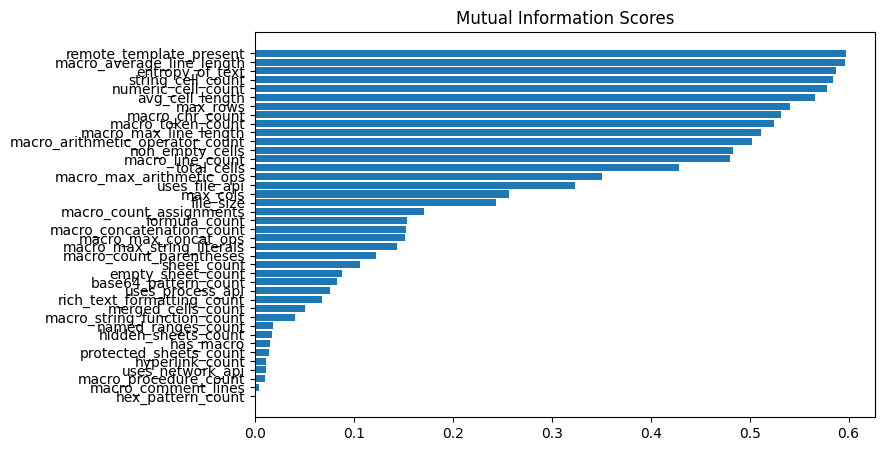

In [27]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_train_v2_series)

### Feature vs Feature

In [28]:
def mi_matrix(X_data, y_dummy, cols, discrete_list):
    result = pd.DataFrame(index=cols, columns=cols, dtype=float)
    is_disc = [col in discrete_list for col in cols]
    for col in cols:
        scores = mutual_info_regression(X_data[cols], X_data[col],
                                          discrete_features=is_disc, random_state=42)
        result[col] = scores
    return result

top_features = ['remote_template_present', 'entropy_of_text', 'avg_cell_length',
                 'macro_average_line_length', 'macro_chr_count', 'macro_token_count',
                 'macro_max_line_length', 'macro_arithmetic_operator_count',
                 'string_cell_count', 'numeric_cell_count', 'max_rows', 'total_cells']

redundancy = mi_matrix(X_train, None, top_features, discrete_flags)
print(redundancy)

                                 remote_template_present  entropy_of_text  \
remote_template_present                         1.072261         0.774044   
entropy_of_text                                 0.772420         7.501714   
avg_cell_length                                 0.776314         1.200263   
macro_average_line_length                       1.220427         3.331024   
macro_chr_count                                 0.538051         0.712640   
macro_token_count                               0.722826         1.183421   
macro_max_line_length                           0.715645         1.132479   
macro_arithmetic_operator_count                 0.681028         1.034172   
string_cell_count                               2.338861         2.052979   
numeric_cell_count                              2.870879         1.481704   
max_rows                                        4.211129         1.186869   
total_cells                                     0.675335         1.032704   

---

## 3. Constructing the *Unified Features*


we will classify features as the following:
- **Binary features** :
  - sum and take the max

- **Skewed features**:
  1. use log to handle outliers
  2. deal with it as count features

- **Count features**:
  1. min-max for norm (0.0 - 1.0)
  2. mean of all values


> *Note*: some features might need to be mathematically constructed to obtain an approximation on the unified feature across formats



In [29]:
def calculate_content_density (col, clean_df):
  token = clean_df[col]
  total_tokens = clean_df['macro_token_count']
  return np.where (total_tokens > 0, token / total_tokens, 0)

def calculate_sheet_ratio (col, clean_df):
  sheet_type = clean_df [col]
  total_sheets = clean_df ['sheet_count']
  return np.where (total_sheets > 0, sheet_type / total_sheets, 0)

def calculate_cell_density (col, clean_df):
  cell_type = clean_df [col]
  total_cells = clean_df ['total_cells']
  return np.where (total_cells > 0, cell_type / total_cells, 0)

# text_volume
# denom = clean_df['non_empty_cells'].replace(0, np.nan)
clean_df['text_volume'] = np.where(
    clean_df['non_empty_cells'] > 0,
    clean_df['avg_cell_length'] * (clean_df['string_cell_count'] + clean_df['numeric_cell_count']) / clean_df['non_empty_cells'],
    0
)

# renaming remote_template_present to remote_template_count
clean_df['remote_template_count'] = clean_df['remote_template_present']
clean_df = clean_df.drop(columns=['remote_template_present'])

# comment density -> active_content_density
clean_df['comment_density'] = np.where(
    clean_df['macro_line_count'] > 0,
    clean_df['macro_comment_lines'] / clean_df['macro_line_count'],
    0
)

# macro complexity category (parantheses & assignments) -> active_content_density
clean_df ['parentheses_density'] = calculate_content_density ('macro_count_parentheses', clean_df)
clean_df ['assignments_density'] = calculate_content_density ('macro_count_assignments', clean_df)


# string reconstruction category (chr & concat & str fun) -> obfsucation_score
clean_df ['chr_density'] = calculate_content_density ('macro_chr_count', clean_df)
clean_df ['concatenation_density'] = calculate_content_density ('macro_concatenation_count', clean_df)
clean_df ['string_functions_density'] = calculate_content_density ('macro_string_function_count', clean_df)

# expression complexity (arthimatic opr) -> obfsucation_score
clean_df ['arthimatic_opr_density'] = calculate_content_density ('macro_arithmetic_operator_count', clean_df)


# workbook level score (hidden, protected, empty) -> structure_complexity_score
clean_df ['hidden_sheets_ratio'] = calculate_sheet_ratio ('hidden_sheets_count', clean_df)
clean_df ['protected_sheets_ratio'] = calculate_sheet_ratio ('protected_sheets_count', clean_df)
clean_df ['empty_sheets_ratio'] = calculate_sheet_ratio ('empty_sheet_count', clean_df)

# calculate sheet area -> structure_complexity_score
sheet_area = clean_df ['max_rows'] * clean_df ['max_cols']
clean_df ['worksheet_dimensions_score'] = np.log1p(sheet_area)

# worksheet_content_score -> structure_complexity_score
clean_df ['formula_density'] = calculate_cell_density ('formula_count', clean_df)

# presentation_layout_score (txt format, merged cells) -> structure_complexity_score
clean_df ['text_formatting_density'] = calculate_cell_density ('rich_text_formatting_count', clean_df)
clean_df ['merged_cells_density'] = calculate_cell_density ('merged_cells_count', clean_df)

clean_df.shape

/tmp/ipykernel_1170/2151738898.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['text_volume'] = np.where(
/tmp/ipykernel_1170/2151738898.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['remote_template_count'] = clean_df['remote_template_present']


(13972, 57)

In [30]:
# check for skewed features
def find_skewed_columns(X, threshold=1.0):

    numeric_data = X.select_dtypes(include="number")


    skewness = numeric_data.skew().sort_values(
        key=abs,
        ascending=False
    )

    skewed_columns = skewness[skewness.abs() >= threshold]

    return skewed_columns

skewed_columns = find_skewed_columns(
    clean_df,
    threshold=30.0
)

print(skewed_columns)

hex_pattern_count              118.203215
macro_max_concat_ops            84.459625
formula_count                   80.000774
total_cells                     78.857747
rich_text_formatting_count      78.776615
macro_comment_lines             77.982389
macro_max_string_literals       74.946768
parentheses_density             70.628655
macro_count_parentheses         70.396730
base64_pattern_count            69.608407
macro_procedure_count           66.605217
macro_string_function_count     65.191600
macro_count_assignments         63.118714
hyperlink_count                 58.390941
named_ranges_count              58.178980
arthimatic_opr_density          55.176223
macro_concatenation_count       52.109039
merged_cells_count              51.847775
comment_density                 50.394317
concatenation_density           48.014899
string_functions_density        43.893832
chr_density                     43.476466
protected_sheets_count          39.501208
remote_template_count           36

In [31]:
LOG_COLUMNS = {
    'hex_pattern_count',
    'macro_max_concat_ops',
    'formula_count',
    'total_cells',
    'rich_text_formatting_count',
    'macro_comment_lines',
    'macro_max_string_literals',
    'parentheses_density',
    'macro_count_parentheses',
    'base64_pattern_count',
    'macro_procedure_count',
    'macro_string_function_count',
    'macro_count_assignments',
    'hyperlink_count',
    'named_ranges_count',
    'arthimatic_opr_density',
    'macro_concatenation_count',
    'merged_cells_count',
    'string_functions_density',
    'comment_density',
    'concatenation_density',
    'chr_density',
    'protected_sheets_count',
    'remote_template_count',
    'avg_cell_length',
    'text_volume',
    'macro_max_arithmetic_ops',
    'macro_average_line_length',
    'max_cols',
}

In [32]:
BINARY_GROUPS = {
    'active_content_score'
}

In [33]:
EXCEL_FEATURES_GROUPS = {
    #1
    "file_size" : [
        'file_size'
    ],

    #2
    "text_size" : [
        'text_volume'
    ],

    #3
    "embedded_objects": [
        0
        ],

    #4
    "active_content_score": [
        'has_macro',
        'uses_file_api',
        'uses_network_api',
        'uses_process_api'
    ],

    #5
    "active_content_density": {
        'avg_macro_size': [
            'macro_token_count',
            'macro_line_count',
            'macro_procedure_count'
        ],
        'comment_density': [
            'comment_density',
        ],
        'macro_complexity_score': [
            'parentheses_density',
            'assignments_density'
        ]
    },


    #6 removed remote_template_count
    "external_reference_count": {
        "external_reference_count": [
            'hyperlink_count',
            'remote_template_count'
        ]
    },

    #7
    "obfuscation_score" : {
        'encoding_score': [
            'base64_pattern_count',
            'hex_pattern_count',
            'entropy_of_text'
        ],
        'string_reconstruction_score': [
            'chr_density',
            'concatenation_density',
            'string_functions_density',
            'macro_max_line_length',
            'macro_average_line_length'
        ],
        'expression_complexity_score': [
            'macro_max_string_literals',
            'macro_max_arithmetic_ops',
            'macro_max_concat_ops',
            'arthimatic_opr_density'
        ]
    },

    #8
    "structural_complexity_score": {
        'workbook_level' :[
            'sheet_count',
            'named_ranges_count',
            'hidden_sheets_ratio',
            'protected_sheets_ratio',
            'empty_sheets_ratio'
        ],
        'worksheet_dimensions' : [
            'worksheet_dimensions_score'
        ],
        'worksheet_content' : [
            'formula_density',
            'total_cells'
        ],
        'presentation_layout' : [
            'merged_cells_density',
            'text_formatting_density'
        ]
    }
}

In [34]:
# split after adding the features
X_uni = clean_df.drop(columns=["label"])
y_uni = clean_df["label"]

X_uni_train, X_uni_test, y_uni_train, y_uni_test = train_test_split(
    X_uni,
    y_uni,
    test_size=0.3,
    random_state=42,
    stratify=y_uni
)

In [35]:
# ceate dataframes that only contains the indcies of X_uni_train and X_uni_test
X_train_grouped = pd.DataFrame(index=X_uni_train.index)
X_test_grouped = pd.DataFrame(index=X_uni_test.index)
group_scalers = {}
scaler = MinMaxScaler()

# loop through every group (total of 8 iterations)
for group_name, spec in EXCEL_FEATURES_GROUPS.items():

    # --- Handle the embedded_objects placeholder (no real data, fixed 0) ---
    if spec == [0]:
        X_train_grouped[group_name] = 0
        X_test_grouped[group_name] = 0
        continue # to end the loop here and go to the next group

    # --- Detect flat groups (list of raw columns) vs nested groups (dict of sub-clusters) ---
    is_nested = isinstance(spec, dict)
    sub_specs = spec if is_nested else {group_name: spec} # if it's already a dict, use it as-is. If it's a flat list, wrap it into a fake single-entry dict {"file_size": ['file_size']}

    # collect one computed number-per-row for each sub-cluster.
    sub_train_scores = {}
    sub_test_scores = {}

    for sub_name, columns in sub_specs.items():

        missing_columns = [c for c in columns if c not in X_uni_train.columns]
        if missing_columns:
            print(group_name, sub_name, "missing:", missing_columns)
            continue

        # take a copy of columns of the subcluster only, from the cleaf_df copy
        train_values = X_uni_train[columns].copy()
        test_values = X_uni_test[columns].copy()

        # Log-transform BEFORE scaling — write back into train_values/test_values, not the output frame
        for col in columns:
            if col in LOG_COLUMNS:
                train_values[col] = np.log1p(train_values[col].clip(lower=0))
                test_values[col] = np.log1p(test_values[col].clip(lower=0))

        # get max for binary columns
        if group_name == "active_content_score":
            sub_train_scores[sub_name] = train_values.max(axis=1)
            sub_test_scores[sub_name] = test_values.max(axis=1)

        # scaling non-binary columns and get their mean
        else:
            train_scaled = scaler.fit_transform(train_values)
            test_scaled = scaler.transform(test_values) # becomes np array

            train_scaled = pd.DataFrame(
                train_scaled,
                index=train_values.index,
                columns=train_values.columns
            )

            test_scaled = pd.DataFrame(
                test_scaled,
                index=test_values.index,
                columns=test_values.columns
            )

            sub_train_scores[sub_name] = train_scaled.mean(axis=1)
            sub_test_scores[sub_name] = test_scaled.mean(axis=1)

            group_scalers[f"{group_name}.{sub_name}"] = scaler


    # --- Roll up sub-cluster scores into the final unified feature ---
    if not sub_train_scores:
        continue

    sub_train_df = pd.DataFrame(sub_train_scores)
    sub_test_df = pd.DataFrame(sub_test_scores)

    X_train_grouped[group_name] = sub_train_df.mean(axis=1) # skipna=True
    X_test_grouped[group_name] = sub_test_df.mean(axis=1)

In [36]:
# Excel
# models : RF, DT, XGBoost
evaluate_models (X_train_grouped, X_test_grouped, y_uni_train, y_uni_test, 'unified features')


,Experiment,Model,Accuracy,Precision,Recall,F1
0,unified features,Decision Tree,1.0,1.0,1.0,1.0
1,unified features,Random Forest,1.0,1.0,1.0,1.0
2,unified features,XGBoost,1.0,1.0,1.0,1.0


In [37]:
# check for duplicates on each split
print("Duplicate rows:", clean_df.duplicated().sum())
print("Duplicate features:", X_uni.duplicated().sum())

# check if there is shared rows on both train and test -- ensuring it's leakage safe
train_rows = set(map(tuple, X_uni_train.values))
test_rows = set(map(tuple, X_uni_test.values))
print("Shared train/test rows:", len(train_rows & test_rows))

Duplicate rows: 0
Duplicate features: 0
Shared train/test rows: 0


In [38]:
# calculate correlation for all features with the label
temp = X_train_grouped.copy()
temp["label"] = y_uni_train

print(temp.corr(numeric_only=True)["label"].sort_values(ascending=False))

label                          1.000000
external_reference_count       0.244631
text_size                      0.175871
file_size                      0.063968
obfuscation_score              0.038474
active_content_density        -0.158603
structural_complexity_score   -0.608475
active_content_score          -0.620670
embedded_objects                    NaN
Name: label, dtype: float64


In [39]:
# check the shape for each split
print(X_train_grouped.shape)
print(X_test_grouped.shape)
print(y_uni_train.shape)
print(y_uni_test.shape)

(9780, 8)
(4192, 8)
(9780,)
(4192,)


In [40]:
# check that X_train and X_test do not contain the same data
print(X_train_grouped.head())
print(X_test_grouped.head())

       file_size  text_size  embedded_objects  active_content_score  \
17426   0.000159   0.173133                 0                   0.0   
11376   0.047576   0.260083                 0                   1.0   
1996    0.006752   0.296246                 0                   0.0   
19453   0.007045   0.218529                 0                   0.0   
2074    0.012748   0.599859                 0                   1.0   

       active_content_density  external_reference_count  obfuscation_score  \
17426                0.000248                  0.140833           0.079328   
11376                0.021238                  0.054482           0.117508   
1996                 0.091713                  0.239300           0.129158   
19453                0.000045                  0.000000           0.086953   
2074                 0.000030                  0.000000           0.152537   

       structural_complexity_score  
17426                     0.151179  
11376                     0.23

In [41]:
# check the accuracy for each column
for col in X_train_grouped.columns:

    tree = DecisionTreeClassifier(random_state=42)

    tree.fit(X_train_grouped[[col]], y_uni_train)

    pred = tree.predict(X_test_grouped[[col]])

    print(col, accuracy_score(y_uni_test, pred))

file_size 0.8029580152671756
text_size 0.990219465648855
embedded_objects 0.7156488549618321
active_content_score 0.8513835877862596
active_content_density 0.9010019083969466
external_reference_count 1.0
obfuscation_score 0.9632633587786259
structural_complexity_score 0.9312977099236641


In [42]:
from sklearn.metrics import confusion_matrix

rf = RandomForestClassifier(
    n_estimators=250,
    random_state=42
)

rf.fit(X_train_grouped, y_uni_train)

pred = rf.predict(X_test_grouped)

print(confusion_matrix(y_uni_test, pred))

[[3000    0]
 [   0 1192]]


In [43]:
# Compute RF feature importance on the Unified feature set !!
rf_model = RandomForestClassifier (
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42

            )

rf_model.fit(X_train_grouped, y_uni_train)

importances = rf_model.feature_importances_
feat_importance_df = pd.DataFrame({
    'feature': X_train_grouped.columns,   # the feature names, in the same order as importances
    'importance': importances     # the corresponding importance score
})


# We zip names + scores together into a table since the raw importances

feat_importance_df = feat_importance_df.sort_values('importance', ascending=False)
# Sort descending so the most influential feature is at the top.

print(feat_importance_df.head(10))

                       feature  importance
5     external_reference_count    0.230072
1                    text_size    0.186966
4       active_content_density    0.152996
7  structural_complexity_score    0.151989
6            obfuscation_score    0.143151
3         active_content_score    0.097914
0                    file_size    0.036912
2             embedded_objects    0.000000


In [44]:
# Combine the grouped features
X_grouped = pd.concat([X_train_grouped, X_test_grouped])

# Put rows back in their original order
X_grouped = X_grouped.sort_index()

# Add the label
X_grouped["label"] = y_uni.loc[X_grouped.index]

# Save
X_grouped.to_csv("excel_unified_features.csv", index=False)